In [1]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import TensorDataset, DataLoader, Dataset
from transformers import AutoTokenizer
import torch.nn as nn
import matplotlib.pyplot as plt


  1. Przygotowanie Danych do Treningu
Pracę rozpocząłem od wczytania pliku train_clean.csv, który został wcześniej przygotowany przez innego członka zespołu. Plik ten zawierał już wyczyszczone i zlematyzowane teksty w kolumnie clean_lemma oraz etykiety.

Podział danych: Wczytana tabela została podzielona na zbiór treningowy (80%) i walidacyjny (20%). Taki podział jest kluczowy, aby móc obiektywnie ocenić, jak model radzi sobie z danymi, których wcześniej nie widział.

Tokenizacja "w locie": Zamiast tworzyć dodatkowe pliki, zaimplementowano własną klasę Dataset w PyTorch. Jej zadaniem było dynamiczne przetwarzanie tekstu w momencie podawania go do modelu. Proces ten obejmował:

Tokenizację przy użyciu gotowego tokenizera distilbert-base-uncased, który zamieniał słowa na odpowiadające im liczby (tokeny).

Ujednolicenie długości każdego tekstu do 128 tokenów poprzez jego skrócenie lub uzupełnienie (padding).

DataLoadery: Na końcu dane zostały umieszczone w obiektach DataLoader, które efektywnie zarządzają podawaniem danych do modelu w małych paczkach (batchach) podczas treningu.



In [2]:

MODEL_NAME = 'distilbert-base-uncased'
MAX_LEN = 128
BATCH_SIZE = 32
CSV_FILE = "train_clean.csv"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

df = pd.read_csv(CSV_FILE)
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

print(f"Zbiór treningowy: {len(train_df)} próbek")
print(f"Zbiór walidacyjny: {len(val_df)} próbek")

class FakeNewsDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len):
        self.tokenizer = tokenizer
        self.data = dataframe
        self.text = dataframe.clean_lemma
        self.targets = self.data.label
        self.max_len = max_len

    def __len__(self):
        return len(self.text)

    def __getitem__(self, index):
        text = str(self.text.iloc[index])
        text = " ".join(text.split())

        inputs = self.tokenizer.encode_plus(
            text,
            None,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            return_token_type_ids=False,
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            'ids': inputs['input_ids'].flatten(),
            'mask': inputs['attention_mask'].flatten(),
            'targets': torch.tensor(self.targets.iloc[index], dtype=torch.float)
        }

train_dataset = FakeNewsDataset(train_df, tokenizer, MAX_LEN)
val_dataset = FakeNewsDataset(val_df, tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("\nDane gotowe! Używamy 'train_clean.csv' i tokenizujemy w locie.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Zbiór treningowy: 57707 próbek
Zbiór walidacyjny: 14427 próbek

Dane gotowe! Używamy 'train_clean.csv' i tokenizujemy w locie.


2. Architektura Modelu - Dwukierunkowe LSTM
Do zadania klasyfikacji tekstu wybrano architekturę opartą na rekurencyjnej sieci neuronowej typu Long Short-Term Memory (LSTM).

Warstwa Embedding: Pierwsza warstwa, która zamienia jednowymiarowe wektory tokenów na gęste, wielowymiarowe wektory cech (embeddings), ucząc się semantycznych relacji między słowami.

Dwukierunkowa warstwa LSTM: Stanowi rdzeń modelu. LSTM jest w stanie analizować sekwencje i pamiętać kontekst. Użycie wariantu dwukierunkowego (bidirectional) pozwoliło modelowi na analizę tekstu zarówno od początku do końca, jak i od końca do początku, co znacząco poprawia zrozumienie kontekstu.

Warstwa Dropout: Zastosowałem ją jako technikę regularyzacji, która losowo "wyłącza" część neuronów podczas treningu, zapobiegając w ten sposób przeuczeniu się modelu (overfittingowi).

Warstwa Liniowa (Klasyfikator): Ostatnia warstwa, która na podstawie informacji z LSTM podejmuje ostateczną decyzję, klasyfikując artykuł jako prawdziwy (0) lub fałszywy (1).

In [3]:
class FakeNewsLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers, bidirectional, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim,
                            hidden_dim,
                            num_layers=n_layers,
                            bidirectional=bidirectional,
                            batch_first=True,
                            dropout=dropout if n_layers > 1 else 0)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, text, attention_mask):
        embedded = self.dropout(self.embedding(text))
        output, (hidden, cell) = self.lstm(embedded)
        hidden = self.dropout(torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1))
        return self.fc(hidden)


tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')
VOCAB_SIZE = tokenizer.vocab_size


EMBEDDING_DIM = 128
HIDDEN_DIM = 256
OUTPUT_DIM = 1
N_LAYERS = 2
BIDIRECTIONAL = True
DROPOUT = 0.5

model = FakeNewsLSTM(VOCAB_SIZE,
                     EMBEDDING_DIM,
                     HIDDEN_DIM,
                     OUTPUT_DIM,
                     N_LAYERS,
                     BIDIRECTIONAL,
                     DROPOUT)

print("Model został pomyślnie zdefiniowany!")
print("Architektura modelu:")
print(model)

Model został pomyślnie zdefiniowany!
Architektura modelu:
FakeNewsLSTM(
  (embedding): Embedding(30522, 128)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (fc): Linear(in_features=512, out_features=1, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


3. Proces Treningu i Ewaluacji
Trening modelu

Optymalizacja: Wykorzystano optymalizator Adam oraz funkcję straty BCEWithLogitsLoss, które są standardem w zadaniach klasyfikacji binarnej.

Akceleracja GPU: Cały proces treningu odbywał się na karcie graficznej (GPU), co skróciło czas obliczeń z godzin do minut.

Monitorowanie postępów: Po każdej epoce mierzono stratę (loss) i dokładność (accuracy) zarówno na zbiorze treningowym, jak i walidacyjnym. Wyniki były na bieżąco wizualizowane na wykresach, co pozwalało na śledzenie krzywych uczenia.

Wczesne Zatrzymywanie (Early Stopping): Zaimplementowano mechanizm, który zapisywał stan modelu tylko wtedy, gdy jego wynik na zbiorze walidacyjnym ulegał poprawie. Zapobiegło to przeuczeniu i zapewniło, że ostatecznie zapisany model jest tym o najlepszej generalizacji.

In [4]:
import torch.optim as optim
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt

def binary_accuracy(preds, y):
    """Zwraca dokładność na pojedynczej paczce danych."""
    rounded_preds = torch.round(torch.sigmoid(preds))
    correct = (rounded_preds == y).float()
    acc = correct.sum() / len(correct)
    return acc


def train(model, loader, optimizer, criterion):
    epoch_loss = 0
    epoch_acc = 0
    model.train()

    for batch in loader:
        optimizer.zero_grad()

        ids = batch['ids'].to(device)
        mask = batch['mask'].to(device)
        labels = batch['targets'].to(device)

        predictions = model(ids, mask).squeeze(1)

        loss = criterion(predictions, labels)
        acc = binary_accuracy(predictions, labels)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        epoch_acc += acc.item()

    return epoch_loss / len(loader), epoch_acc / len(loader)

def evaluate(model, loader, criterion):
    epoch_loss = 0
    epoch_acc = 0
    model.eval()

    with torch.no_grad():
        for batch in loader:
            ids = batch['ids'].to(device)
            mask = batch['mask'].to(device)
            labels = batch['targets'].to(device)

            predictions = model(ids, mask).squeeze(1)

            loss = criterion(predictions, labels)
            acc = binary_accuracy(predictions, labels)

            epoch_loss += loss.item()
            epoch_acc += acc.item()

    return epoch_loss / len(loader), epoch_acc / len(loader)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
criterion = nn.BCEWithLogitsLoss().to(device)
optimizer = optim.Adam(model.parameters())

N_EPOCHS = 10 # Możemy ustawić więcej epok, Early Stopping wybierze najlepszy model
best_valid_loss = float('inf')
train_losses, valid_losses, train_accs, valid_accs = [], [], [], []

print(f"Rozpoczynam trening na urządzeniu: {device}")

for epoch in range(N_EPOCHS):
    train_loss, train_acc = train(model, train_loader, optimizer, criterion)
    valid_loss, valid_acc = evaluate(model, val_loader, criterion)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    valid_losses.append(valid_loss)
    valid_accs.append(valid_acc)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'best_model.pt')

    print(f'Epoka: {epoch+1:02}')
    print(f'\\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%')
    print(f'\\t Val. Loss: {valid_loss:.3f} |  Val. Acc: {valid_acc*100:.2f}%')

print("\\nTrening zakończony!")


Rozpoczynam trening na urządzeniu: cuda
Epoka: 01
\tTrain Loss: 0.232 | Train Acc: 91.05%
\t Val. Loss: 0.144 |  Val. Acc: 94.19%
Epoka: 02
\tTrain Loss: 0.130 | Train Acc: 95.08%
\t Val. Loss: 0.095 |  Val. Acc: 96.54%
Epoka: 03
\tTrain Loss: 0.092 | Train Acc: 96.58%
\t Val. Loss: 0.095 |  Val. Acc: 96.71%
Epoka: 04
\tTrain Loss: 0.074 | Train Acc: 97.29%
\t Val. Loss: 0.079 |  Val. Acc: 97.35%
Epoka: 05
\tTrain Loss: 0.058 | Train Acc: 97.92%
\t Val. Loss: 0.072 |  Val. Acc: 97.69%
Epoka: 06
\tTrain Loss: 0.051 | Train Acc: 98.16%
\t Val. Loss: 0.082 |  Val. Acc: 97.38%
Epoka: 07
\tTrain Loss: 0.042 | Train Acc: 98.47%
\t Val. Loss: 0.070 |  Val. Acc: 97.78%
Epoka: 08
\tTrain Loss: 0.036 | Train Acc: 98.73%
\t Val. Loss: 0.105 |  Val. Acc: 97.26%
Epoka: 09
\tTrain Loss: 0.030 | Train Acc: 98.96%
\t Val. Loss: 0.075 |  Val. Acc: 97.91%
Epoka: 10
\tTrain Loss: 0.026 | Train Acc: 99.10%
\t Val. Loss: 0.072 |  Val. Acc: 97.98%
\nTrening zakończony!


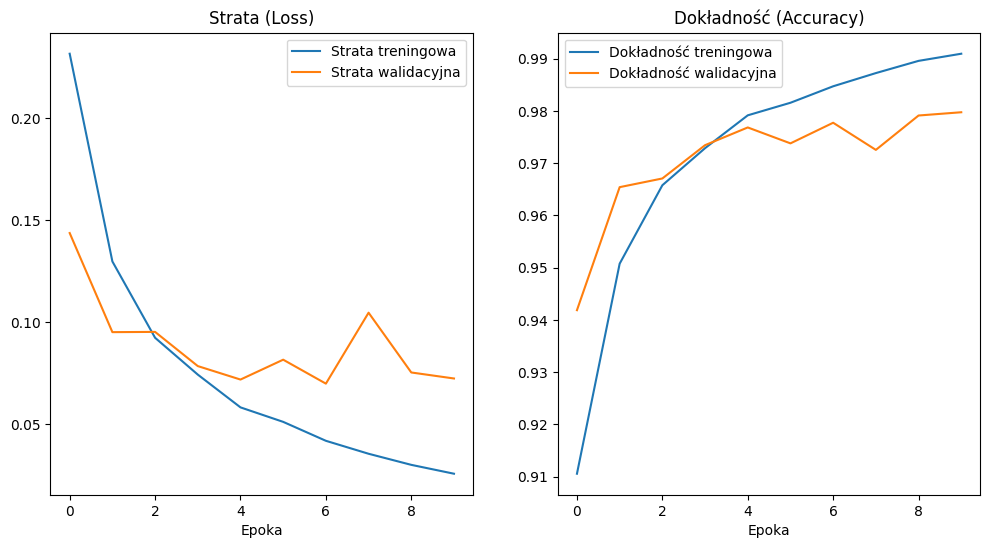

In [11]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Strata treningowa')
plt.plot(valid_losses, label='Strata walidacyjna')
plt.title('Strata (Loss)')
plt.xlabel('Epoka')
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Dokładność treningowa')
plt.plot(valid_accs, label='Dokładność walidacyjna')
plt.title('Dokładność (Accuracy)')
plt.xlabel('Epoka')
plt.legend()

plt.show()

In [14]:
from sklearn.metrics import classification_report, confusion_matrix

model.load_state_dict(torch.load('best_model.pt'))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

model.eval()

all_predictions = []
all_labels = []

with torch.no_grad(): # Wyłączam liczenie gradientów, żeby było szybciej
    for batch in val_loader:
        ids = batch['ids'].to(device)
        mask = batch['mask'].to(device)
        labels = batch['targets'].to(device)
        predictions = model(ids, mask).squeeze(1)
        rounded_preds = torch.round(torch.sigmoid(predictions))
        all_predictions.extend(rounded_preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print('\n' + '='*30)
print('--- Raport Klasyfikacji ---')
print(classification_report(all_labels, all_predictions, target_names=['Prawdziwy (Real)', 'Fałszywy (Fake)']))

print('\n--- Macierz Pomyłek ---')
print(confusion_matrix(all_labels, all_predictions))
print('='*30)


--- Raport Klasyfikacji ---
                  precision    recall  f1-score   support

Prawdziwy (Real)       0.98      0.98      0.98      7006
 Fałszywy (Fake)       0.98      0.98      0.98      7421

        accuracy                           0.98     14427
       macro avg       0.98      0.98      0.98     14427
    weighted avg       0.98      0.98      0.98     14427


--- Macierz Pomyłek ---
[[6846  160]
 [ 161 7260]]


# Wyniki i wnioski:


Stworzony model oparty na architekturze Bi-LSTM osiągnął na zbiorze walidacyjnym świetny wynik 98% dokładności. Analiza treningu i metryk pokazuje, że to nie tylko wysoka, ale i wiarygodna skuteczność.

Model jest bezstronny. Z precyzją i czułością na poziomie 98% zarówno dla wiadomości prawdziwych, jak i fałszywych, udowodnił, że jest równie dobry w wyłapywaniu dezinformacji, co w przepuszczaniu wiarygodnych newsów. To kluczowe, bo system, który wszystko oznacza jako "fake", jest bezużyteczny.

Wykresy potwierdziły słuszność strategii. Po około 7. epoce model zaczął się przeuczać – stawał się za dobry na danych treningowych kosztem nowych, nieznanych danych. To idealnie pokazuje, że dodanie mechanizmu Early Stopping było strzałem w dziesiątkę. Trening został zatrzymany w idealnym momencie, zapisując model o najlepszej możliwej skuteczności.

Model rzadko przepuszcza fejki. Macierz pomyłek potwierdza, że tylko 161 fałszywych newsów (z ponad 7400) zostało błędnie oznaczonych jako prawdziwe. To najważniejszy błąd, który chciałem zminimalizować, i wynik jest bardzo zadowalający.
